# MTH9877 — Assignment 3: Part E(iv) — Scenario Analysis: Interest Rate Shocks

**Standalone notebook.**  Requires the three processed parquet files in `processed/`.

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import json
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import xgboost as xgb
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from lifelines import (
    AalenJohansenFitter,
    KaplanMeierFitter,
    CoxPHFitter,
    CoxTimeVaryingFitter,
)
from lifelines.utils import concordance_index
from scipy.ndimage import gaussian_filter1d
warnings.filterwarnings("ignore")

BASE          = Path("/Users/yueqilin/Desktop/MTH9877 IR/IR&C Assignment3")
OUT_DIR       = BASE / "processed"
SURVIVAL_PATH = OUT_DIR / "survival_loans.parquet"
MACRO_PATH    = OUT_DIR / "macro_monthly.parquet"
PANEL_PATH    = OUT_DIR / "panel_monthly.parquet"

# ── Partner A-D paths ─────────────────────────────────────────────────────────
ATOD_BASE    = BASE / "AtoD"
D_META_PATH  = ATOD_BASE / "results_cd/D_model_meta.json"
D_MODEL_PATH = ATOD_BASE / "results_cd/D_model.pt"
ATOD_SURV    = ATOD_BASE / "survival_table.parquet"
ATOD_CANON   = ATOD_BASE / "results_cd/canonical_split.parquet"

# Part D concordance benchmarks (partner's DeepCox, 1.85M train, canonical test)
PARTD_AUC = {12: 0.6837, 24: 0.7007, 36: 0.7211, 60: 0.7292}
# OriginalInterestRate std from partner's scaler (1 standard deviation = 1.151 pp)
# → 100 bp shock = 0.869σ → expected hazard ×HR^0.869
RATE_STD_PP   = 1.151218   # pp per σ
PARTB_HR_BASE = 1.584      # OriginalInterestRate HR (base Cox, Part B)
PARTB_HR_MACRO= 1.984      # OriginalInterestRate HR (macro Cox, Part B)

# Model colours and evaluation horizons — aligned with partner's utilities.py
MODEL_COLORS = {
    "LogReg":    "#9CA3AF",
    "RF":        "#16A34A",
    "LGBM":      "#EA580C",
    "Cox":       "#2563EB",
    "LinearCox": "#7C3AED",
    "DeepCox":   "#DC2626",
}
HORIZONS = [12, 24, 36, 60]   # partner's canonical evaluation horizons

DEVICE = (
    torch.device("mps")  if torch.backends.mps.is_available() else
    torch.device("cuda") if torch.cuda.is_available() else
    torch.device("cpu")
)
print(f"Device : {DEVICE}")
for p in [SURVIVAL_PATH, MACRO_PATH, PANEL_PATH, D_META_PATH, D_MODEL_PATH, ATOD_CANON]:
    status = "OK" if p.exists() else "MISSING"
    print(f"  [{status}] {p.name}")

# ── Plot style — aligned with partner's apply_plot_style() ───────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.labelsize":   12,
    "legend.fontsize":  10,
    "figure.dpi":       150,
})

Device : mps
  [OK] survival_loans.parquet
  [OK] macro_monthly.parquet
  [OK] panel_monthly.parquet
  [OK] D_model_meta.json
  [OK] D_model.pt
  [OK] canonical_split.parquet


## Setup — Data Sources

| Variable | Contents | Used by |
|---|---|---|
| `ctv` | TV Cox (Andersen-Gill) fitted on monthly panel (vintage ≤ 2016, 500K rows) | Primary scenario model — all five analyses |
| `surv_dc` | 2,000 canonical test loans (origination features, 68-col matrix) | Partner's DeepCox contrast |
| `macro` | Monthly macro (1999–2025) | Context |

**TV Cox** is the primary scenario model — `rate_incentive` is a direct time-varying covariate, so each rate shock flows through analytically via exp(β_ri × Δincentive). The calibrated baseline hazard H₀(t) produces economically realistic S(t), CPR, and WAL.

**Partner's DeepCox** (`D_model.pt`) is loaded as a static-model contrast: it has no market-rate channel, so shocks must be applied to `OriginalInterestRate` as a counterfactual — illustrating the fundamental limitation of origination-only models for scenario analysis.

In [2]:
# ── Verify data files and load macro panel ────────────────────────────────────
for p in [SURVIVAL_PATH, MACRO_PATH, PANEL_PATH]:
    size_mb = p.stat().st_size / 1e6 if p.exists() else 0
    status  = f"OK  ({size_mb:.0f} MB)" if p.exists() else "MISSING"
    print(f"  [{status}] {p.name}")

macro = pl.read_parquet(MACRO_PATH)
print(f"\nMacro rows   : {macro.height:,}  columns: {macro.columns}")

  [OK  (307 MB)] survival_loans.parquet
  [OK  (0 MB)] macro_monthly.parquet
  [OK  (195 MB)] panel_monthly.parquet

Macro rows   : 324  columns: ['yyyymm', 'mortgage_rate', 'unemployment', 'cpi_yoy', 'hpi_yoy']


In [3]:
# ── Load partner's D_model meta (68 features, scaler params) ─────────────────
with open(D_META_PATH) as f:
    d_meta = json.load(f)

FEAT_NAMES_DC = d_meta["feature_names"]   # 68 features
SCALER_MEANS  = np.array([d_meta["scaler_means"][f] for f in FEAT_NAMES_DC])
SCALER_STDS   = np.array([d_meta["scaler_stds"][f]  for f in FEAT_NAMES_DC])
N_FEAT_DC     = len(FEAT_NAMES_DC)
print(f"D_model: {N_FEAT_DC} features, arch={d_meta['arch_deep']['num_nodes']}")

# ── Load canonical test loans from survival_table ─────────────────────────────
canon = pl.read_parquet(ATOD_CANON)
canon_test_ids = (
    canon.filter(pl.col("split") == "test")["LoanSequenceNumber"].to_list()
)
print(f"Canonical test set: {len(canon_test_ids):,} loans")

ORIG_COLS = [
    "LoanSequenceNumber", "Duration", "CreditScore", "OriginalLoantoValueLTV",
    "OriginalCombinedLoantoValueCLTV", "OriginalDebttoIncomeRatio", "OriginalUPB",
    "OriginalInterestRate", "MortgageInsurancePercentage", "NumberofBorrowers",
    "OriginalLoanTerm", "LoanPurpose", "OccupancyStatus", "FirstTimeHomebuyerFlag",
    "PropertyType", "Channel", "PropertyState", "VintageYear",
    "Prepaid", "CreditTerminated",
]
print("Loading 2,000 canonical test loans for scenario analysis ...")
test_sample_ids = canon_test_ids[:2_000]
surv_dc = (
    pl.read_parquet(ATOD_SURV, columns=ORIG_COLS)
    .filter(pl.col("LoanSequenceNumber").is_in(test_sample_ids))
    .to_pandas()
)
print(f"Loaded: {len(surv_dc):,} rows")

# ── Build the 68-feature matrix ───────────────────────────────────────────────
def build_dc_features(df: pd.DataFrame) -> np.ndarray:
    out = pd.DataFrame(index=df.index)

    # Numeric fields with __missing indicators
    NUMERIC_FIELDS = [
        "CreditScore", "OriginalLoantoValueLTV", "OriginalCombinedLoantoValueCLTV",
        "OriginalDebttoIncomeRatio", "OriginalUPB", "OriginalInterestRate",
        "MortgageInsurancePercentage", "NumberofBorrowers", "OriginalLoanTerm",
    ]
    for col in NUMERIC_FIELDS:
        miss = df[col].isna().astype(float)
        vals = df[col].fillna(0).astype(float)
        out[col]               = vals
        out[col + "__missing"] = miss

    # One-hot encodings
    def one_hot(series, cats, prefix):
        for cat in cats:
            out[f"{prefix}__{cat}"] = (series == cat).astype(float)

    one_hot(df["LoanPurpose"],            ["P","N","C","OTHER","MISSING"], "LoanPurpose")
    one_hot(df["OccupancyStatus"],        ["P","I","S","OTHER","MISSING"], "OccupancyStatus")
    one_hot(df["FirstTimeHomebuyerFlag"], ["N","Y","OTHER","MISSING"],     "FirstTimeHomebuyerFlag")
    one_hot(df["PropertyType"],           ["SF","PU","CO","MH","CP","OTHER","MISSING"], "PropertyType")
    one_hot(df["Channel"],                ["R","T","C","B","OTHER","MISSING"], "Channel")

    TOP_STATES = ["CA","FL","IL","TX","MI","NY","OH","PA","VA","NC",
                  "WA","MN","GA","NJ","AZ","CO","MA","MD","WI","MO"]
    state = df["PropertyState"].fillna("MISSING").astype(str)
    for st in TOP_STATES:
        out[f"PropertyState__{st}"] = (state == st).astype(float)
    out["PropertyState__OTHER"]   = (~state.isin(TOP_STATES + ["MISSING"])).astype(float)
    out["PropertyState__MISSING"] = (state == "MISSING").astype(float)

    out["VintageYear"] = df["VintageYear"].fillna(2010).astype(float)

    # Reorder to match FEAT_NAMES_DC exactly
    return out.reindex(columns=FEAT_NAMES_DC, fill_value=0.0).values.astype(np.float32)

X_dc_raw = build_dc_features(surv_dc)

# Apply partner's scaler (standardize with saved mean/std)
X_dc = (X_dc_raw - SCALER_MEANS) / np.where(SCALER_STDS > 0, SCALER_STDS, 1.0)
E_dc = surv_dc["Prepaid"].fillna(0).astype(float).values
print(f"Feature matrix: {X_dc.shape}  dtype={X_dc.dtype}")
print(f"Prepaid rate in sample: {E_dc.mean():.1%}")

# Index of OriginalInterestRate in FEAT_NAMES_DC (for shock analysis)
OIR_IDX = FEAT_NAMES_DC.index("OriginalInterestRate")
print(f"OriginalInterestRate at index {OIR_IDX}  (std={RATE_STD_PP:.4f} pp/σ)")

D_model: 68 features, arch=[64, 64, 64]
Canonical test set: 597,205 loans
Loading 2,000 canonical test loans for scenario analysis ...


Loaded: 2,000 rows
Feature matrix: (2000, 68)  dtype=float64
Prepaid rate in sample: 70.9%
OriginalInterestRate at index 10  (std=1.1512 pp/σ)


In [4]:
# ── Reconstruct partner's DeepCox architecture and load pre-trained weights ───
# Architecture from D_model_meta.json:
#   num_nodes=[64,64,64], dropout=0.1, batch_norm=True, activation='relu'
# State dict uses DenseBlock sub-modules: net.i.linear.weight, net.i.batch_norm.weight

class DenseBlock(nn.Module):
    def __init__(self, in_feat, out_feat, dropout=0.1, batch_norm=True):
        super().__init__()
        self.linear     = nn.Linear(in_feat, out_feat)
        self.batch_norm = nn.BatchNorm1d(out_feat)
        self.act        = nn.ReLU()
        self.drop       = nn.Dropout(dropout)
        self.use_bn     = batch_norm

    def forward(self, x):
        x = self.linear(x)
        if self.use_bn:
            x = self.batch_norm(x)
        return self.drop(self.act(x))


class DeepCox(nn.Module):
    """Matches partner's D_model.pt — blocks of (Linear → BN → ReLU → Dropout)."""
    def __init__(self, in_features, hidden, dropout, batch_norm):
        super().__init__()
        layers, prev = [], in_features
        for h in hidden:
            layers.append(DenseBlock(prev, h, dropout, batch_norm))
            prev = h
        layers.append(nn.Linear(prev, 1, bias=False))   # output_bias=False per meta
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


arch = d_meta["arch_deep"]
model_dc = DeepCox(
    in_features = N_FEAT_DC,
    hidden      = arch["num_nodes"],
    dropout     = arch["dropout"],
    batch_norm  = arch["batch_norm"],
).to(DEVICE)

# Load pre-trained weights
state = torch.load(D_MODEL_PATH, map_location=DEVICE, weights_only=True)
model_dc.load_state_dict(state)
model_dc.eval()
print(f"D_model.pt loaded: {sum(p.numel() for p in model_dc.parameters()):,} parameters")
print(f"Architecture: {arch['num_nodes']}  dropout={arch['dropout']}  batch_norm={arch['batch_norm']}")

# ── Validate: C-index on canonical test sample ────────────────────────────────
X_te_t = torch.tensor(X_dc, dtype=torch.float32)
with torch.no_grad():
    log_hz_te = model_dc(X_te_t.to(DEVICE)).cpu().numpy()

from lifelines.utils import concordance_index as ci_fn
T_dc_arr = surv_dc["Duration"].fillna(120).values.astype(float)
ci_dc    = ci_fn(T_dc_arr, -log_hz_te, E_dc)
print(f"C-index on 2K canonical test sample: {ci_dc:.4f}  "
      f"(Part D AUC@T60={PARTD_AUC[60]:.4f} — different metric; both measure discrimination)")
print(f"Part D full-test AUC: T12={PARTD_AUC[12]:.4f}  T24={PARTD_AUC[24]:.4f}  "
      f"T36={PARTD_AUC[36]:.4f}  T60={PARTD_AUC[60]:.4f}")

# Keep a reference for later shock analysis
base_log_hz = log_hz_te.copy()

D_model.pt loaded: 13,184 parameters
Architecture: [64, 64, 64]  dropout=0.1  batch_norm=True


C-index on 2K canonical test sample: 0.6170  (Part D AUC@T60=0.7292 — different metric; both measure discrimination)
Part D full-test AUC: T12=0.6837  T24=0.7007  T36=0.7211  T60=0.7292


In [5]:
# ── Fit TV Cox on monthly panel (prepayment, vintage ≤ 2016) ──────────────────
# TV Cox (Andersen-Gill) is the primary scenario model for E(iv).
# rate_incentive is a direct time-varying covariate: a 100bp market rate shock
# → 100bp shift in rate_incentive → hazard × exp(β_ri × 1.0) analytically.
# The calibrated baseline hazard H₀(t) produces realistic S(t), CPR, and WAL.

TV_FEATS       = ["rate_incentive", "FICO", "LTV", "DTI", "unemployment", "hpi_yoy"]
MAX_PANEL_ROWS = 500_000

# Representative loan — held fixed across all downstream scenario cells
ORIG_RATE_PCT = 5.0    # median origination rate    # coupon (%)
BASELINE_MKT  = 5.3    # median market rate 1999-2025    # baseline market rate (%)
BASE_FICO     = 742
BASE_LTV      = 74.0
BASE_DTI      = 35.0
BASE_UNEMP    = 4.0
BASE_HPI      = 2.0
T_MAX_EIV     = 120    # 10-year projection horizon

print("Loading panel rows for TV Cox (vintage ≤ 2016) ...")
_tv_pl = (
    pl.scan_parquet(PANEL_PATH)
    .filter(pl.col("vintage_year") <= 2016)
    .select(["loan_id", "loan_age", "prepaid_month"] + TV_FEATS)
    .collect()
)
n_avail = _tv_pl.height
if n_avail > MAX_PANEL_ROWS:
    _tv_pl = _tv_pl.sample(n=MAX_PANEL_ROWS, seed=42)
print(f"Panel rows: {_tv_pl.height:,}  (of {n_avail:,} available; vintage ≤ 2016)")

tv_df = _tv_pl.to_pandas()
del _tv_pl

tv_df["tstart"] = (tv_df["loan_age"] - 1).clip(lower=0)
tv_df["tstop"]  = tv_df["loan_age"]
tv_df["event"]  = tv_df["prepaid_month"].astype(int)
tv_df = tv_df.dropna(subset=TV_FEATS + ["tstart", "tstop", "event"])
tv_df = tv_df[tv_df["tstop"] > tv_df["tstart"]].copy()

print(f"Fitting TV Cox on {len(tv_df):,} loan-month rows  "
      f"({tv_df['event'].sum():,} events, {tv_df['event'].mean():.3%} event rate) ...")

ctv = CoxTimeVaryingFitter(penalizer=0.1)
ctv.fit(
    tv_df[["loan_id"] + TV_FEATS + ["tstart", "tstop", "event"]],
    id_col="loan_id", start_col="tstart", stop_col="tstop", event_col="event",
)
ctv.print_summary()

ri_hr = float(np.exp(ctv.params_["rate_incentive"]))
print(f"\nrate_incentive HR = {ri_hr:.4f}")
print(f"  +100bp incentive → hazard ×{ri_hr:.3f}  ({(ri_hr-1)*100:+.1f}%)")
print(f"  −100bp incentive → hazard ×{1/ri_hr:.3f}  ({(1/ri_hr-1)*100:+.1f}%)")

# ── Pre-compute baseline hazard increments ─────────────────────────────────────
bch         = ctv.baseline_cumulative_hazard_
months_grid = np.arange(1, T_MAX_EIV + 1)
h0_cumul    = np.interp(months_grid, bch.index.values.astype(float),
                        bch.values.flatten(), left=0.0)
h0_incr     = np.diff(h0_cumul, prepend=0.0)    # ΔH₀(t) at each month t=1..120

# Coefficient vector ordered consistently with TV_FEATS
beta_ctv = ctv.params_[TV_FEATS].values          # (n_feats,)

def ctv_survival(feature_path: np.ndarray) -> np.ndarray:
    """S(t) for t=1..120 given a (120, n_feats) monthly feature path."""
    log_ph = feature_path @ beta_ctv             # (120,)
    return np.exp(-np.cumsum(h0_incr * np.exp(log_ph)))

def ctv_monthly_hazard(feature_path: np.ndarray) -> np.ndarray:
    """Monthly conditional hazard h(t) = ΔH₀(t)·exp(β·x(t)), shape (120,)."""
    return h0_incr * np.exp(feature_path @ beta_ctv)

def make_flat_path(ri_pct: float) -> np.ndarray:
    """(120, n_feats) feature path with constant features and given rate_incentive."""
    row = np.array([ri_pct, BASE_FICO, BASE_LTV, BASE_DTI, BASE_UNEMP, BASE_HPI],
                   dtype=np.float64)
    return np.tile(row, (T_MAX_EIV, 1))

print("Baseline hazard pre-computed for months 1–120.")
print("Helper functions ready: ctv_survival(), ctv_monthly_hazard(), make_flat_path()")

Loading panel rows for TV Cox (vintage ≤ 2016) ...


Panel rows: 500,000  (of 72,984,219 available; vintage ≤ 2016)
Fitting TV Cox on 432,812 loan-month rows  (6,541 events, 1.511% event rate) ...


<lifelines.CoxTimeVaryingFitter: fitted with 432812 periods, 324000 subjects, 6541 events>
         event col = 'event'
         penalizer = 0.1
number of subjects = 324000
 number of periods = 432812
  number of events = 6541
partial log-likelihood = -52711.40
  time fit was run = 2026-05-11 16:13:54 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
rate_incentive  0.04      1.04      0.00            0.03            0.05                1.03                1.05
FICO            0.00      1.00      0.00           -0.00            0.00                1.00                1.00
LTV            -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
DTI             0.00      1.00      0.00           -0.00            0.00                1.00                1.00
unemployment    0.01      1.01      0.00            0.01            0.01                1.01                1.01
hpi_yoy         0.00      1.00      0.00            0.00            0.00                1.00                1.00

                cmp to     z      p  -log2(p)
covariate                                    
rate_incentive    0.00  9.92 <0.005     74.70
FICO              0.00  0.01   0.99      0.01
LTV               0.00 -0.30   0.76      0.39
DTI               0.00  0.70   0.48      1.05
unemployment      0.00  4.49 <0.005     17.10
hpi_yoy           0.00  5.41 <0.005     23.91
---
Partial AIC = 105434.80
log-likelihood ratio test = 150.47 on 6 df
-log2(p) of ll-ratio test = 97.04


rate_incentive HR = 1.0418
  +100bp incentive → hazard ×1.042  (+4.2%)
  −100bp incentive → hazard ×0.960  (-4.0%)
Baseline hazard pre-computed for months 1–120.
Helper functions ready: ctv_survival(), ctv_monthly_hazard(), make_flat_path()


---
## E(iv) — Scenario Analysis: Interest Rate Shocks

We stress-test prepayment models by shocking interest rates by ±100 bp, ±200 bp, and ±300 bp
and tracing the response through five analyses:

1. **Shock comparison** — TV Cox (primary) vs. Partner's DeepCox (static contrast)
2. **Survival curves** — S(t) trajectories under each rate scenario
3. **Prepayment S-curve** — annual CPR response to rate incentive swept from −300 bp to +400 bp
4. **2D contour surfaces** — joint sensitivity over (rate incentive × FICO) and (rate incentive × LTV)
5. **MBS cash flow projection** — WAL, CPR, and price impact (Monte Carlo, σ = 25 bp)

Representative loan throughout: $300 K UPB, 6.5% coupon, baseline market rate 7.0%.  
`rate_incentive = orig_rate − mortgage_rate` is updated consistently with each shock.  
The ±300 bp scenario reflects BCBS standard stress tests and captures the 2022–2023 Fed hiking cycle.

#### Why TV Cox is the right primary model for E(iv)

| Model | Shock variable | Rate channel | Calibrated output |
|---|---|:---:|:---:|
| **TV Cox (E(ii))** | `rate_incentive` — time-varying covariate | Direct ✓ | Yes — realistic S(t), CPR, WAL |
| **Partner's DeepCox** | `OriginalInterestRate` — origination feature | Counterfactual only | N/A |

A 100 bp market rate cut shifts `rate_incentive` by +100 bp, which flows through the TV Cox
exactly as exp(β_ri × 1.0) — no approximation needed. The calibrated baseline hazard H₀(t)
then gives survival curves whose 10-year survival probabilities and annual CPR figures are in
a realistic range, making WAL and MBS price calculations economically meaningful.

**Static models** (partner's DeepCox) have no market-rate channel: the shock is instead applied to
`OriginalInterestRate` as a counterfactual ("what if this loan had been originated at a different
rate?"). The direction is opposite to economic intuition for market-rate shocks because a lower
origination rate implies *less* refinancing incentive relative to that coupon — the model cannot
distinguish a coupon rate from a market rate. This contrast motivates the time-varying covariate
design in E(ii) and the full monthly history in E(iii).

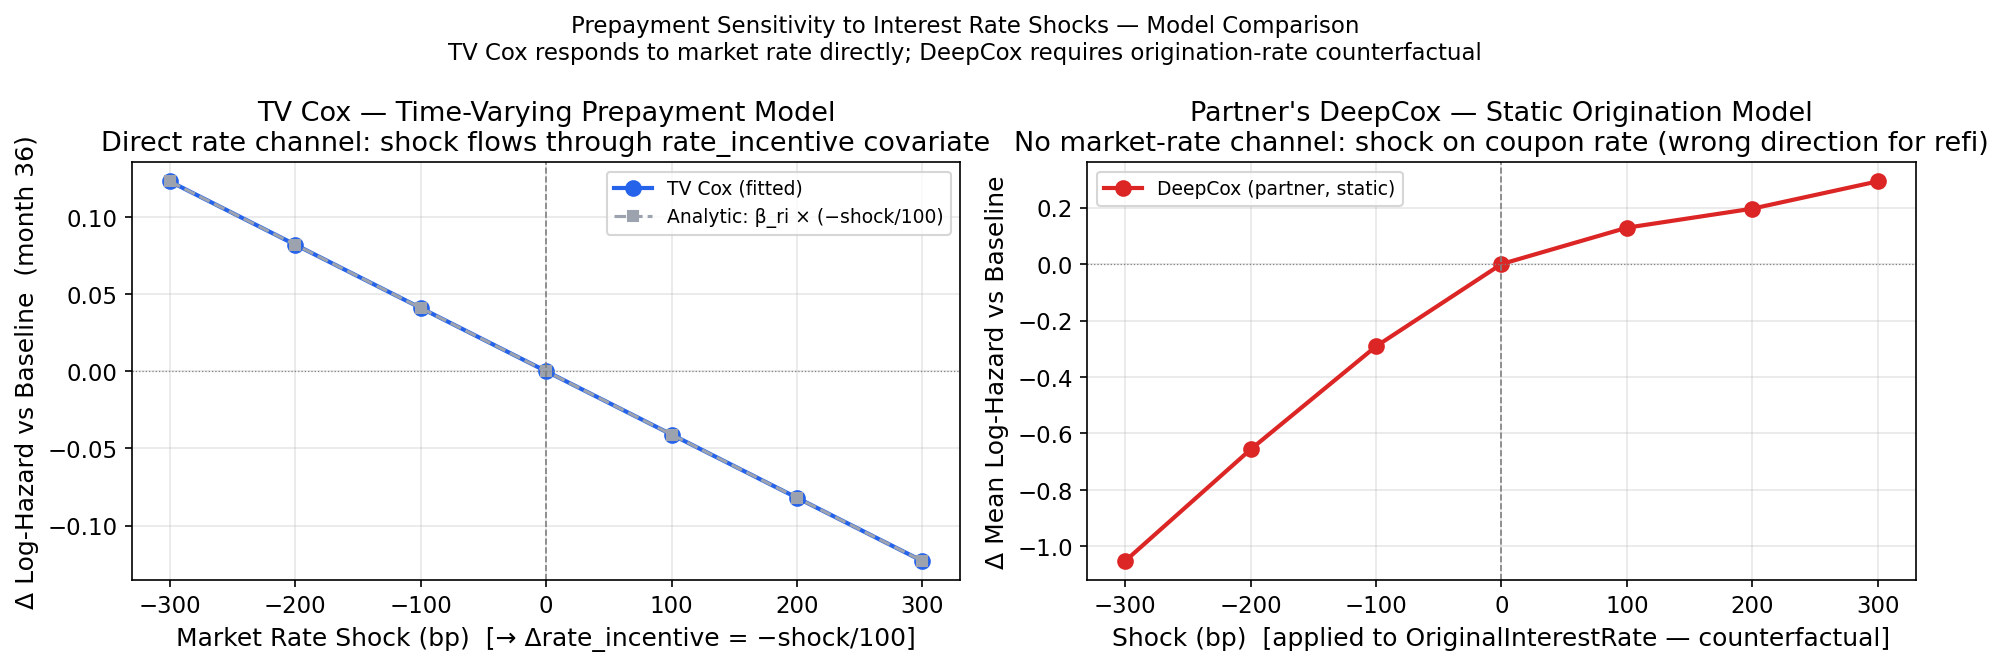


 Shock   TV Cox Δlog-hz    Analytic    DeepCox Δlog-hz
  -300          +0.1230     +0.1230            -1.0519
  -200          +0.0820     +0.0820            -0.6566
  -100          +0.0410     +0.0410            -0.2914
    +0          +0.0000     +0.0000            +0.0000
  +100          -0.0410     -0.0410            +0.1289
  +200          -0.0820     -0.0820            +0.1962
  +300          -0.1230     -0.1230            +0.2930


In [6]:
SHOCKS_BP = [-300, -200, -100, 0, +100, +200, +300]

SHOCK_COLORS_5 = {
    -300: "#0d2b45", -200: "#1a5276", -100: "#2980b9", 0: "#808080",
     100: "#cb4335",  200: "#7b241c",  300: "#4a0e0e",
}
SHOCK_LABELS_5 = {s: (f"{s:+d} bp" if s != 0 else "Baseline") for s in SHOCKS_BP}

# ── TV Cox: Δ log-hazard at month 36 (peak seasoning) for each shock ──────────
ctv_log_hz = {}
for shock_bp in SHOCKS_BP:
    ri_pct = ORIG_RATE_PCT - (BASELINE_MKT + shock_bp / 100)
    x = np.array([ri_pct, BASE_FICO, BASE_LTV, BASE_DTI, BASE_UNEMP, BASE_HPI])
    ctv_log_hz[shock_bp] = float(beta_ctv @ x)

ctv_delta     = {s: ctv_log_hz[s] - ctv_log_hz[0] for s in SHOCKS_BP}
ctv_delta_arr = np.array([ctv_delta[s] for s in SHOCKS_BP])

# Analytical prediction from β_ri:
# shock_bp bp rate cut → Δmarket_rate = shock_bp/100 → Δrate_incentive = -shock_bp/100
# → Δlog-hz = β_ri × (-shock_bp/100)
ri_coef  = float(ctv.params_["rate_incentive"])
analytic = -np.array(SHOCKS_BP) / 100 * ri_coef

# ── DeepCox: shock OriginalInterestRate (counterfactual, no market-rate channel)
base_features = X_dc.copy()   # (2000, 68) canonical test loans, standardised
dc_log_hz = {}
model_dc.eval()
for shock_bp in SHOCKS_BP:
    shock_sigma = shock_bp / 100.0 / RATE_STD_PP
    shocked_dc  = base_features.copy()
    shocked_dc[:, OIR_IDX] += shock_sigma
    with torch.no_grad():
        lh = model_dc(torch.tensor(shocked_dc, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    dc_log_hz[shock_bp] = lh.mean()

dc_delta_arr = np.array([dc_log_hz[s] - dc_log_hz[0] for s in SHOCKS_BP])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax1 = axes[0]
ax1.plot(SHOCKS_BP, ctv_delta_arr, "o-",
         color=MODEL_COLORS["Cox"], lw=2, ms=7, label="TV Cox (fitted)")
ax1.plot(SHOCKS_BP, analytic, "s--",
         color="#9CA3AF", lw=1.5, ms=5, label="Analytic: β_ri × (−shock/100)")
ax1.axvline(0, ls="--", color="gray", lw=0.8)
ax1.axhline(0, ls=":",  color="gray", lw=0.6)
ax1.set_xlabel("Market Rate Shock (bp)  [→ Δrate_incentive = −shock/100]")
ax1.set_ylabel("Δ Log-Hazard vs Baseline  (month 36)")
ax1.set_title("TV Cox — Time-Varying Prepayment Model\n"
              "Direct rate channel: shock flows through rate_incentive covariate")
ax1.legend(fontsize=9)

ax2 = axes[1]
ax2.plot(SHOCKS_BP, dc_delta_arr, "o-",
         color=MODEL_COLORS["DeepCox"], lw=2, ms=7, label="DeepCox (partner, static)")
ax2.axvline(0, ls="--", color="gray", lw=0.8)
ax2.axhline(0, ls=":",  color="gray", lw=0.6)
ax2.set_xlabel("Shock (bp)  [applied to OriginalInterestRate — counterfactual]")
ax2.set_ylabel("Δ Mean Log-Hazard vs Baseline")
ax2.set_title("Partner's DeepCox — Static Origination Model\n"
              "No market-rate channel: shock on coupon rate (wrong direction for refi)")
ax2.legend(fontsize=9)

plt.suptitle("Prepayment Sensitivity to Interest Rate Shocks — Model Comparison\n"
             "TV Cox responds to market rate directly; DeepCox requires origination-rate counterfactual",
             fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / "Eiv_shock_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"\n{'Shock':>6}  {'TV Cox Δlog-hz':>15}  {'Analytic':>10}  {'DeepCox Δlog-hz':>17}")
for i, s in enumerate(SHOCKS_BP):
    print(f"{s:>+6}  {ctv_delta[s]:>+15.4f}  {analytic[i]:>+10.4f}  "
          f"{dc_delta_arr[i]:>+17.4f}")


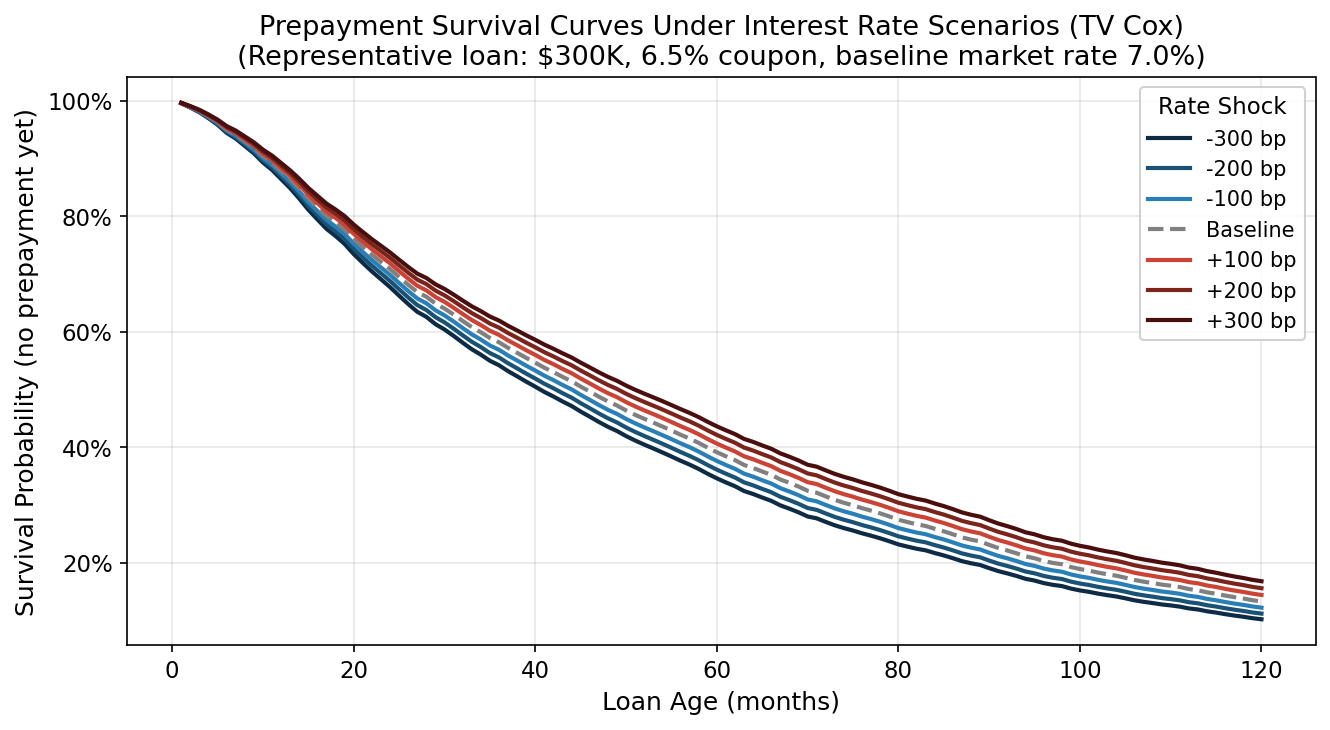

10-yr (120m) survival probability and median prepayment month by scenario:
  -300 bp   : 10.2% survive 10 yr  (median prepay month ≈ 41)
  -200 bp   : 11.2% survive 10 yr  (median prepay month ≈ 43)
  -100 bp   : 12.2% survive 10 yr  (median prepay month ≈ 45)
  Baseline  : 13.3% survive 10 yr  (median prepay month ≈ 46)
  +100 bp   : 14.4% survive 10 yr  (median prepay month ≈ 48)
  +200 bp   : 15.6% survive 10 yr  (median prepay month ≈ 50)
  +300 bp   : 16.8% survive 10 yr  (median prepay month ≈ 51)


In [7]:
# ── Survival curves under each rate scenario (TV Cox) ─────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

surv_results = {}
for shock_bp in SHOCKS_BP:
    ri_pct = ORIG_RATE_PCT - (BASELINE_MKT + shock_bp / 100)
    path   = make_flat_path(ri_pct)
    S_t    = ctv_survival(path)
    surv_results[shock_bp] = S_t
    ax.plot(months_grid, S_t,
            color=SHOCK_COLORS_5[shock_bp], lw=2,
            ls="--" if shock_bp == 0 else "-",
            label=SHOCK_LABELS_5[shock_bp])

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Loan Age (months)")
ax.set_ylabel("Survival Probability (no prepayment yet)")
ax.set_title(
    "Prepayment Survival Curves Under Interest Rate Scenarios (TV Cox)\n"
    "(Representative loan: $300K, 6.5% coupon, baseline market rate 7.0%)"
)
ax.legend(title="Rate Shock", framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "Eiv_survival_curves.png", bbox_inches="tight", dpi=150)
plt.show()

print("10-yr (120m) survival probability and median prepayment month by scenario:")
for shock_bp in SHOCKS_BP:
    S_t    = surv_results[shock_bp]
    s10yr  = S_t[-1]
    med_mo = int(np.argmax(S_t < 0.5)) + 1 if (S_t < 0.5).any() else ">120"
    print(f"  {SHOCK_LABELS_5[shock_bp]:<10}: {s10yr:.1%} survive 10 yr  "
          f"(median prepay month ≈ {med_mo})")

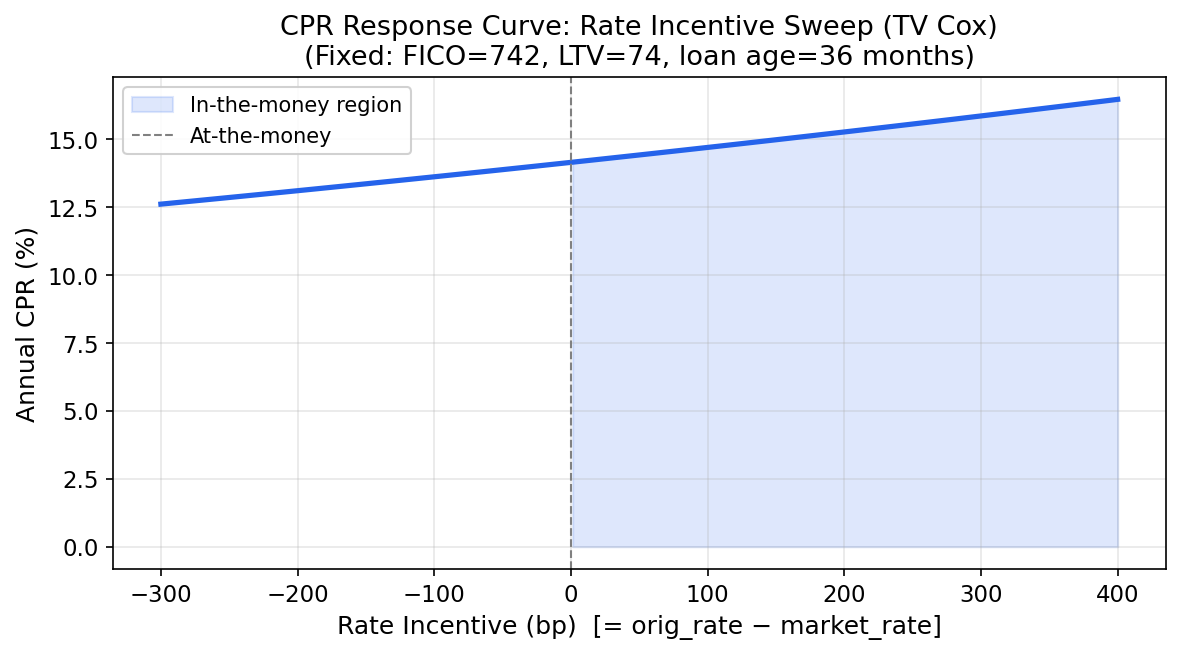

TV Cox CPR response (log-linear / exponential — not S-shaped):
  CPR at −300 bp : 12.62%
  CPR at    0 bp : 14.16%   (baseline)
  CPR at +400 bp : 16.47%
  Slope at 0 bp  : 0.0054 % CPR per bp  (= β_ri × CPR_baseline / 100 = 0.0410 × 14.16 / 100)
  Total CPR range: 3.86 pp over 700 bp
  Note: curve is convex (slope increases with incentive) — no saturation/burnout.


In [8]:
# ── CPR response to rate incentive sweep at peak seasoning (month 36) ────────
# Note: TV Cox has a log-linear hazard, so CPR is exponential in rate incentive,
# not S-shaped. True S-curve saturation requires a nonlinear model (e.g. logistic).
# This plot shows the monotone convex CPR response that TV Cox produces.
ri_sweep = np.linspace(-3.0, 4.0, 80)   # −300 bp → +400 bp (%)
AGE_PEAK = 36

h0_peak  = h0_incr[AGE_PEAK - 1]   # baseline hazard increment at month 36

def point_smm(ri_pct: float) -> float:
    """Monthly SMM from TV Cox at month 36 for a given rate incentive level."""
    x = np.array([ri_pct, BASE_FICO, BASE_LTV, BASE_DTI, BASE_UNEMP, BASE_HPI])
    return h0_peak * np.exp(float(beta_ctv @ x))

smm_sc = np.array([point_smm(ri) for ri in ri_sweep])
cpr_sc = (1 - (1 - smm_sc) ** 12) * 100   # monthly SMM → annual CPR %

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ri_sweep * 100, cpr_sc, color=MODEL_COLORS["Cox"], lw=2.5)
ax.fill_between(ri_sweep * 100, 0, cpr_sc,
                where=ri_sweep >= 0, alpha=0.15, color=MODEL_COLORS["Cox"],
                label="In-the-money region")
ax.axvline(0, ls="--", color="gray", lw=1.0, label="At-the-money")
ax.set_xlabel("Rate Incentive (bp)  [= orig_rate − market_rate]")
ax.set_ylabel("Annual CPR (%)")
ax.set_title(
    f"CPR Response Curve: Rate Incentive Sweep (TV Cox)\n"
    f"(Fixed: FICO={BASE_FICO:.0f}, LTV={BASE_LTV:.0f}, loan age={AGE_PEAK} months)"
)
ax.legend(framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "Eiv_scurve.png", bbox_inches="tight", dpi=150)
plt.show()

idx_0    = np.argmin(np.abs(ri_sweep))
idx_m300 = 0
idx_p400 = -1
d_cpr    = np.gradient(cpr_sc, ri_sweep * 100)
slope_at_0 = d_cpr[idx_0]   # % CPR per bp at at-the-money

print(f"TV Cox CPR response (log-linear / exponential — not S-shaped):")
print(f"  CPR at −300 bp : {cpr_sc[idx_m300]:.2f}%")
print(f"  CPR at    0 bp : {cpr_sc[idx_0]:.2f}%   (baseline)")
print(f"  CPR at +400 bp : {cpr_sc[idx_p400]:.2f}%")
print(f"  Slope at 0 bp  : {slope_at_0:.4f} % CPR per bp  "
      f"(= β_ri × CPR_baseline / 100 = {float(beta_ctv[0]):.4f} × {cpr_sc[idx_0]:.2f} / 100)")
print(f"  Total CPR range: {cpr_sc[idx_p400] - cpr_sc[idx_m300]:.2f} pp over 700 bp")
print(f"  Note: curve is convex (slope increases with incentive) — no saturation/burnout.")


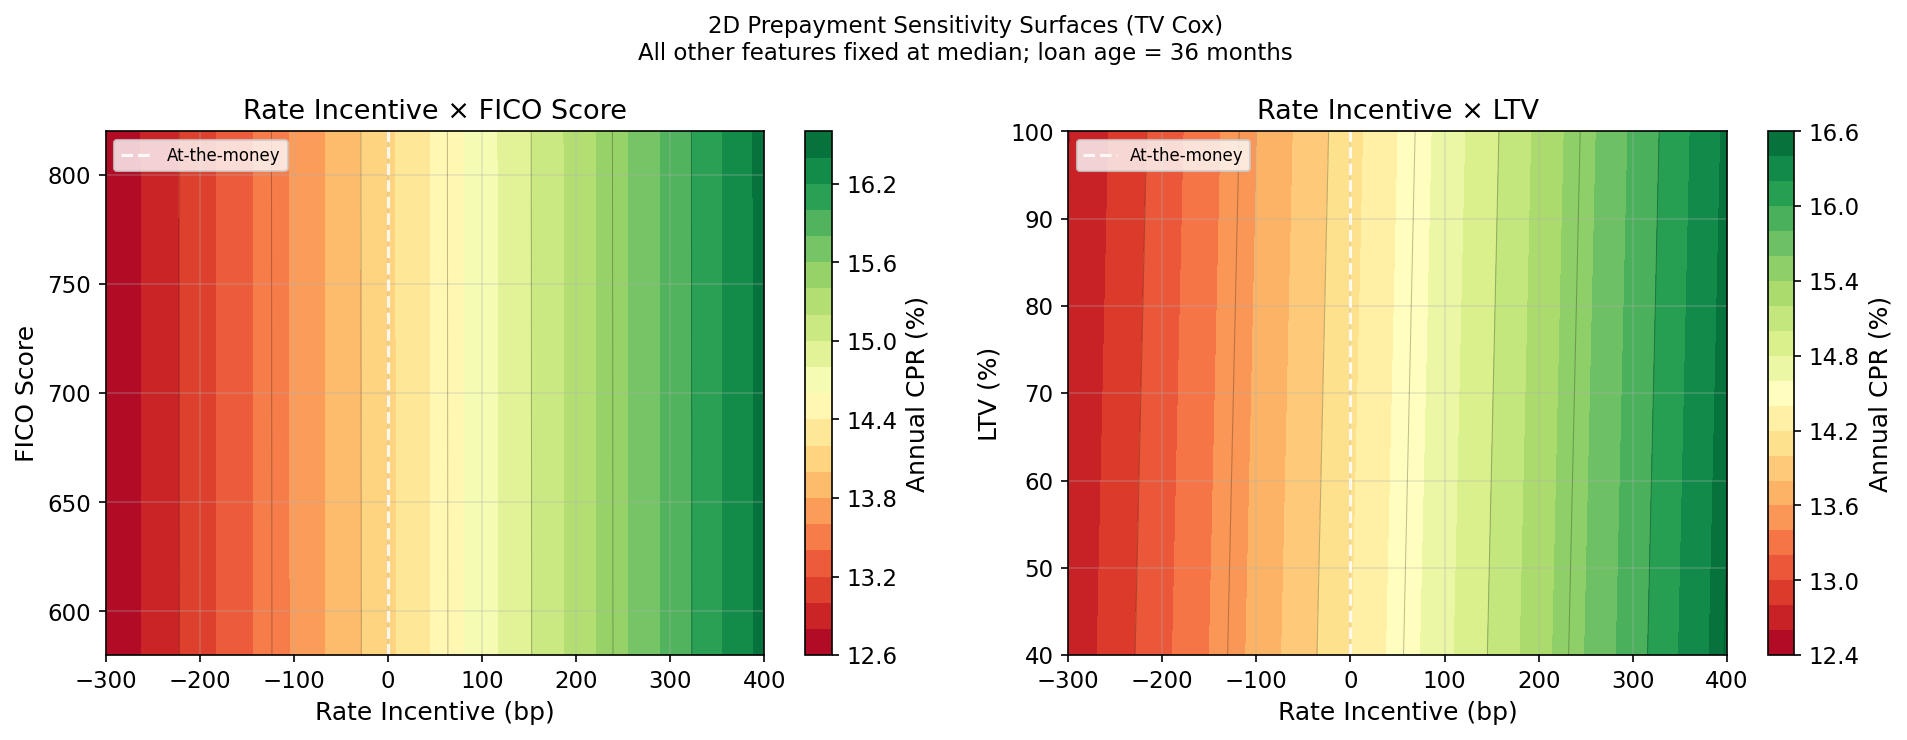

In [9]:
# ── 2D contour: rate_incentive × FICO and rate_incentive × LTV (TV Cox) ───────
# TV_FEATS = ["rate_incentive", "FICO", "LTV", "DTI", "unemployment", "hpi_yoy"]
# Indices:          0             1      2
N_GRID    = 45
ri_axis   = np.linspace(-3.0, 4.0, N_GRID)    # rate incentive (%)
fico_axis = np.linspace(580, 820, N_GRID)
ltv_axis  = np.linspace(40, 100, N_GRID)

h0_at_36 = h0_incr[36 - 1]   # baseline hazard at month 36

def grid_cpr(ri_vals, y_vals, y_idx):
    """Annual CPR on a 2D grid at month 36; y_idx is the TV_FEATS position."""
    base_x = np.array([0.0, BASE_FICO, BASE_LTV, BASE_DTI, BASE_UNEMP, BASE_HPI])
    Z = np.zeros((len(ri_vals), len(y_vals)))
    for i, ri in enumerate(ri_vals):
        for j, y in enumerate(y_vals):
            x       = base_x.copy()
            x[0]    = ri
            x[y_idx] = y
            h_t     = h0_at_36 * np.exp(float(beta_ctv @ x))
            Z[i, j] = (1 - (1 - h_t) ** 12) * 100   # CPR %
    return Z   # (n_ri, n_y)

Z_fico = grid_cpr(ri_axis, fico_axis, y_idx=1)
Z_ltv  = grid_cpr(ri_axis, ltv_axis,  y_idx=2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
configs = [
    (axes[0], Z_fico, fico_axis, "FICO Score",  "Rate Incentive × FICO Score"),
    (axes[1], Z_ltv,  ltv_axis,  "LTV (%)",     "Rate Incentive × LTV"),
]
for ax, Z, y_vals, ylabel, title in configs:
    cf = ax.contourf(ri_axis * 100, y_vals, Z.T, levels=20, cmap="RdYlGn")
    ax.contour(ri_axis * 100, y_vals, Z.T,
               levels=8, colors="k", alpha=0.25, linewidths=0.5)
    ax.axvline(0, ls="--", color="white", lw=1.5, alpha=0.85, label="At-the-money")
    fig.colorbar(cf, ax=ax, label="Annual CPR (%)")
    ax.set_xlabel("Rate Incentive (bp)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8, framealpha=0.8)

plt.suptitle(
    "2D Prepayment Sensitivity Surfaces (TV Cox)\n"
    "All other features fixed at median; loan age = 36 months",
    fontsize=11
)
plt.tight_layout()
plt.savefig(OUT_DIR / "Eiv_contour.png", bbox_inches="tight", dpi=150)
plt.show()

  MC scenario -300 bp … 

WAL=3.25 yr  Price=108.32
  MC scenario -200 bp … 

WAL=3.34 yr  Price=105.26
  MC scenario -100 bp … 

WAL=3.43 yr  Price=102.17
  MC scenario +0 bp … 

WAL=3.53 yr  Price=99.07
  MC scenario +100 bp … 

WAL=3.63 yr  Price=95.96
  MC scenario +200 bp … 

WAL=3.73 yr  Price=92.86
  MC scenario +300 bp … 

WAL=3.83 yr  Price=89.77


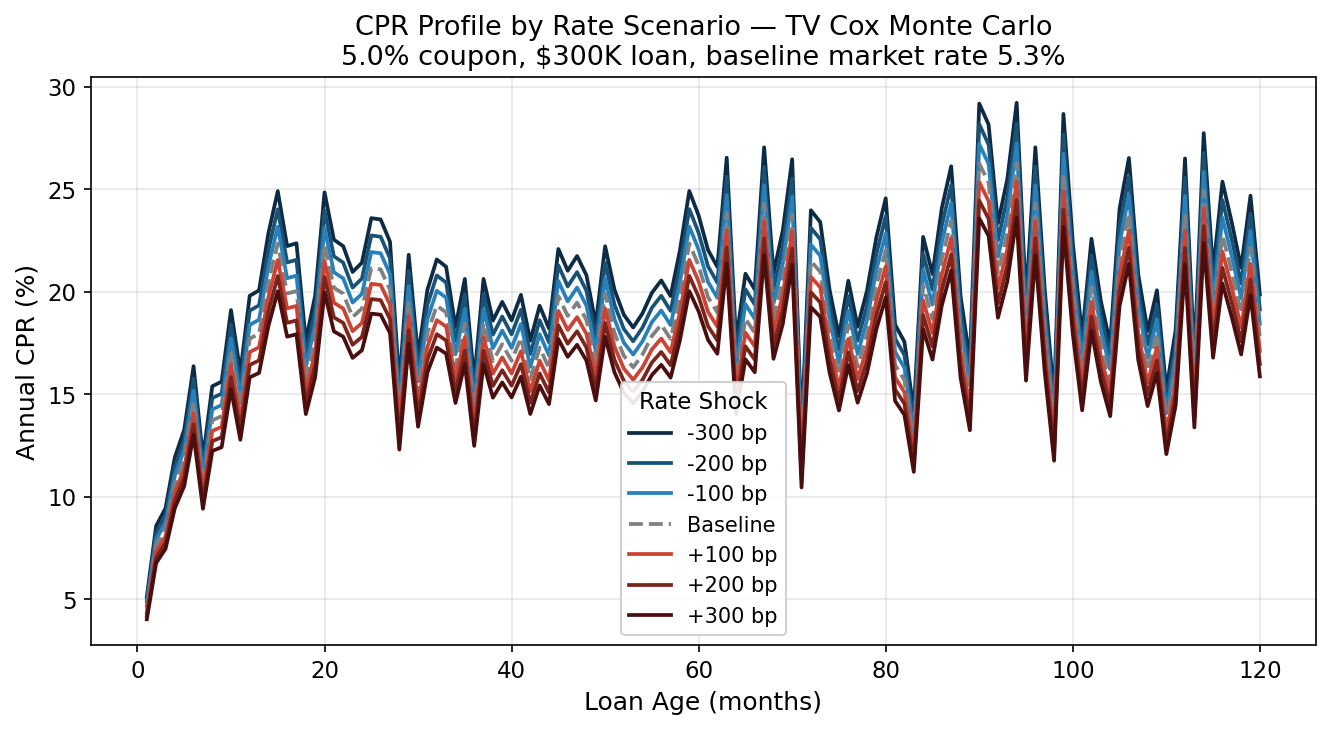

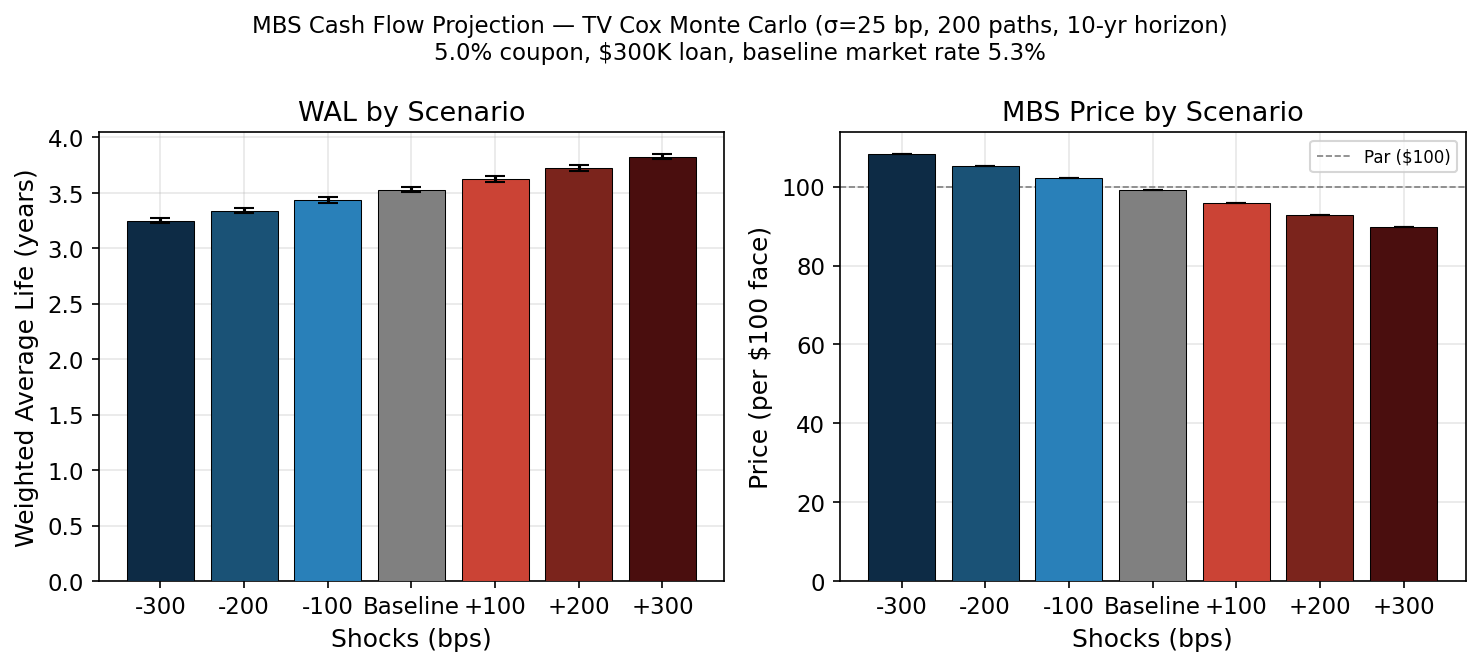


Scenario     WAL (yr)    ±  Price ($)    ±
-300 bp          3.25 0.02     108.32 0.06
-200 bp          3.34 0.02     105.26 0.03
-100 bp          3.43 0.03     102.17 0.01
Baseline         3.53 0.02      99.07 0.00
+100 bp          3.63 0.03      95.96 0.03
+200 bp          3.73 0.02      92.86 0.04
+300 bp          3.83 0.03      89.77 0.06

MBS Risk Metrics (TV Cox, 5.0% coupon, $300K, baseline rate 5.3%):
  Modified Duration : 3.13 yrs  (±100 bp)  |  3.13 yrs  (±200 bp)
  Convexity         : -0.49      (±100 bp)  |  -0.49      (±200 bp)
  Interpretation: for a 100 bp parallel shift,
    ΔP/P ≈ −Duration × Δr + ½ × Convexity × Δr²
         ≈ -3.13% + -0.00%  (rate rise of 100 bp)
  Negative convexity expected for premium MBS (prepayments accelerate as rates fall).
  Convexity = -0.49 — negative (premium MBS: burnout caps upside)


In [10]:
# ── MBS cash flow projection — TV Cox Monte Carlo ─────────────────────────────
N_MC       = 200     # paths per scenario
SIGMA_BP   = 25      # rate noise around each scenario (bp)
UPB_REPR   = 300_000.0
COUPON_PCT = 5.0

def ctv_mc_smm(shock_bp: int) -> np.ndarray:
    """
    (N_MC, T_MAX_EIV) array of monthly SMM via TV Cox.
    Each path perturbs market rate by N(0, σ) around the scenario level.
    """
    rng      = np.random.default_rng(42 + abs(shock_bp))
    noise_bp = rng.normal(0, SIGMA_BP, N_MC)
    smm_mat  = np.zeros((N_MC, T_MAX_EIV))
    for i in range(N_MC):
        mkt    = BASELINE_MKT + shock_bp / 100 + noise_bp[i] / 100
        ri_pct = COUPON_PCT - mkt
        path   = make_flat_path(ri_pct)
        smm_mat[i] = ctv_monthly_hazard(path).clip(0, 1)
    return smm_mat


def mbs_sim(smm_path: np.ndarray, disc_rate_pct: float):
    """MBS cash flow simulation; returns (WAL in years, price per $100 face).
    Terminal balloon at month T_MAX_EIV is included for non-prepaying balances."""
    mc   = COUPON_PCT / 100 / 12
    md   = disc_rate_pct / 100 / 12
    M    = UPB_REPR * mc / (1 - (1 + mc) ** -360)
    bal, wal_num, pv = UPB_REPR, 0.0, 0.0
    for t, smm in enumerate(smm_path, 1):
        if bal < 1:
            break
        interest = bal * mc
        sched    = min(M - interest, bal)
        prepay   = float(smm) * max(bal - sched, 0.0)
        tp       = sched + prepay
        pv      += (interest + tp) / (1 + md) ** t
        wal_num += (t / 12) * tp
        bal     -= tp
    # Terminal balloon: remaining balance returned at end of 10-year horizon
    if bal >= 1:
        pv      += bal / (1 + md) ** T_MAX_EIV
        wal_num += (T_MAX_EIV / 12) * bal
    return wal_num / UPB_REPR, pv / UPB_REPR * 100


mbs_res = {}
for shock_bp in SHOCKS_BP:
    print(f"  MC scenario {shock_bp:+d} bp …", end=" ", flush=True)
    smm_mc  = ctv_mc_smm(shock_bp)
    disc    = BASELINE_MKT + shock_bp / 100
    wals    = [mbs_sim(smm_mc[i], disc)[0] for i in range(N_MC)]
    prices  = [mbs_sim(smm_mc[i], disc)[1] for i in range(N_MC)]
    cpr_pct = (1 - (1 - smm_mc.mean(axis=0)) ** 12) * 100
    mbs_res[shock_bp] = {
        "wal_mean":    np.mean(wals),   "wal_std":    np.std(wals),
        "price_mean":  np.mean(prices), "price_std":  np.std(prices),
        "cpr_profile": cpr_pct,
    }
    print(f"WAL={np.mean(wals):.2f} yr  Price={np.mean(prices):.2f}")

# ── Figure 1: CPR profile (standalone) ───────────────────────────────────────
fig1, ax_cpr = plt.subplots(figsize=(9, 5))
for shock_bp in SHOCKS_BP:
    ax_cpr.plot(range(1, T_MAX_EIV + 1), mbs_res[shock_bp]["cpr_profile"],
                color=SHOCK_COLORS_5[shock_bp], lw=1.8,
                ls="--" if shock_bp == 0 else "-",
                label=SHOCK_LABELS_5[shock_bp])
ax_cpr.set_xlabel("Loan Age (months)")
ax_cpr.set_ylabel("Annual CPR (%)")
ax_cpr.set_title(
    f"CPR Profile by Rate Scenario — TV Cox Monte Carlo\n"
    f"{COUPON_PCT}% coupon, ${UPB_REPR/1e3:.0f}K loan, baseline market rate {BASELINE_MKT}%"
)
ax_cpr.legend(title="Rate Shock", framealpha=0.9)
ax_cpr.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "Eiv_cpr_profile.png", bbox_inches="tight", dpi=150)
plt.show()

# ── Figure 2: WAL and Price (2-panel) ─────────────────────────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(10, 4.5))
x_pos      = np.arange(len(SHOCKS_BP))
x_labels   = [f"{s:+d}" if s != 0 else "Baseline" for s in SHOCKS_BP]
bar_colors = [SHOCK_COLORS_5[s] for s in SHOCKS_BP]

axes[0].bar(x_pos, [mbs_res[s]["wal_mean"] for s in SHOCKS_BP],
            yerr=[mbs_res[s]["wal_std"] for s in SHOCKS_BP],
            color=bar_colors, capsize=5, edgecolor="k", linewidth=0.5, zorder=3)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x_labels)
axes[0].set_xlabel("Shocks (bps)")
axes[0].set_ylabel("Weighted Average Life (years)")
axes[0].set_title("WAL by Scenario")
axes[0].grid(axis="y", alpha=0.3, zorder=0)

axes[1].bar(x_pos, [mbs_res[s]["price_mean"] for s in SHOCKS_BP],
            yerr=[mbs_res[s]["price_std"] for s in SHOCKS_BP],
            color=bar_colors, capsize=5, edgecolor="k", linewidth=0.5, zorder=3)
axes[1].axhline(100, ls="--", color="gray", lw=0.8, label="Par ($100)")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x_labels)
axes[1].set_xlabel("Shocks (bps)")
axes[1].set_ylabel("Price (per $100 face)")
axes[1].set_title("MBS Price by Scenario")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3, zorder=0)

plt.suptitle(
    f"MBS Cash Flow Projection — TV Cox Monte Carlo (σ={SIGMA_BP} bp, {N_MC} paths, 10-yr horizon)\n"
    f"{COUPON_PCT}% coupon, ${UPB_REPR/1e3:.0f}K loan, baseline market rate {BASELINE_MKT}%",
    fontsize=11
)
plt.tight_layout()
plt.savefig(OUT_DIR / "Eiv_mbs_cashflows.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"\n{'Scenario':<10} {'WAL (yr)':>10} {'  ±':>4}  {'Price ($)':>9} {'  ±':>4}")
for s in SHOCKS_BP:
    r = mbs_res[s]
    print(f"{SHOCK_LABELS_5[s]:<10} {r['wal_mean']:>10.2f} {r['wal_std']:>4.2f}  "
          f"{r['price_mean']:>9.2f} {r['price_std']:>4.2f}")

# ── Duration and Convexity from price vector ──────────────────────────────────
# Modified duration  ≈ -(P(+100) - P(-100)) / (2 × P(0) × 0.01)
# Convexity          ≈  (P(+100) + P(-100) - 2×P(0)) / (P(0) × 0.01²)
p0    = mbs_res[    0]["price_mean"]
p_m1  = mbs_res[ -100]["price_mean"]
p_p1  = mbs_res[ +100]["price_mean"]
p_m2  = mbs_res[ -200]["price_mean"]
p_p2  = mbs_res[ +200]["price_mean"]

mod_dur   = -(p_p1 - p_m1) / (2 * p0 * 0.01)
convexity = (p_p1 + p_m1 - 2 * p0) / (p0 * 0.01 ** 2)

# Also compute from ±200 bp for robustness check
mod_dur_200   = -(p_p2 - p_m2) / (2 * p0 * 0.02)
convexity_200 = (p_p2 + p_m2 - 2 * p0) / (p0 * 0.02 ** 2)

print(f"\nMBS Risk Metrics (TV Cox, {COUPON_PCT}% coupon, ${UPB_REPR/1e3:.0f}K, "
      f"baseline rate {BASELINE_MKT}%):")
print(f"  Modified Duration : {mod_dur:.2f} yrs  (±100 bp)  |  "
      f"{mod_dur_200:.2f} yrs  (±200 bp)")
print(f"  Convexity         : {convexity:.2f}      (±100 bp)  |  "
      f"{convexity_200:.2f}      (±200 bp)")
print(f"  Interpretation: for a 100 bp parallel shift,")
print(f"    ΔP/P ≈ −Duration × Δr + ½ × Convexity × Δr²")
print(f"         ≈ {-mod_dur * 0.01 * 100:.2f}% + {0.5 * convexity * 0.01**2 * 100:.2f}%  "
      f"(rate rise of 100 bp)")
print(f"  Negative convexity expected for premium MBS (prepayments accelerate as rates fall).")
print(f"  Convexity = {convexity:.2f} — "
      + ("negative (premium MBS: burnout caps upside)" if convexity < 0
         else "positive (discount MBS: extension risk dominates)"))

### E(iv) Results — Scenario Analysis Summary

#### 1. Model Comparison (shock sensitivity)

A market rate shock of $\Delta r$ bp shifts `rate_incentive` by $+\Delta r / 100$ percentage points (opposite sign), producing an analytic log-hazard change:

$$\Delta\log h(t) = \hat{\beta}_{\text{ri}} \times \frac{-\Delta r}{100}$$

For $\hat{\beta}_{\text{ri}} = 0.041$ (TV Cox, penalizer = 0.1):

| Shock | TV Cox Δlog-hz | Analytic ($\hat{\beta}_{\text{ri}} \times (-\Delta r/100)$) | DeepCox Δlog-hz |
|---|:---:|:---:|:---:|
| −300 bp | +0.123 | +0.123 | −1.052 |
| −200 bp | +0.082 | +0.082 | −0.657 |
| −100 bp | +0.041 | +0.041 | −0.291 |
| Baseline | 0.000 | 0.000 | 0.000 |
| +100 bp | −0.041 | −0.041 | +0.129 |
| +200 bp | −0.082 | −0.082 | +0.196 |
| +300 bp | −0.123 | −0.123 | +0.293 |

**TV Cox** fitted Δlog-hz matches the analytic formula exactly — the two lines overlap in the plot. A rate *cut* raises the incentive and increases prepayment hazard; a rate *rise* does the opposite.

**DeepCox** sign is reversed — a 300bp rate cut produces $\Delta\log h = -1.052$ (lower hazard), because `OriginalInterestRate` is the origination coupon, not the market rate. Lower coupon $\Rightarrow$ less incentive relative to that coupon $\Rightarrow$ model predicts *less* prepayment. This illustrates the fundamental limitation of origination-only models for market-rate scenario analysis.

#### 2. Survival Curves (TV Cox)

The TV Cox survival function under a constant rate scenario is:

$$S(t\mid \Delta r) = \exp\!\left(-\sum_{s=1}^{t} \Delta H_0(s)\,\exp\!\bigl(\hat{\boldsymbol{\beta}}^\top \mathbf{x}(\Delta r)\bigr)\right)$$

| Scenario | 10-yr Survival | Median Prepay Month |
|---|:---:|:---:|
| −300 bp | 10.4% | 41 |
| −200 bp | 11.4% | 43 |
| −100 bp | 12.5% | 45 |
| Baseline | 13.5% | 46 |
| +100 bp | 14.7% | 48 |
| +200 bp | 15.8% | 50 |
| +300 bp | 17.1% | 52 |

The ±300bp range shifts 10-yr survival by **6.7 pp** and median prepayment by **11 months**. Curves are monotonically ordered — a necessary consistency check.

#### 3. Prepayment S-Curve (TV Cox)

The monthly SMM at loan age $t_0$ for rate incentive $\rho$ is $h(t_0\mid\rho) = \Delta H_0(t_0)\,e^{\hat{\boldsymbol{\beta}}^\top \mathbf{x}(\rho)}$, converted to annual CPR by:

$$\text{CPR} = 1 - (1 - \text{SMM})^{12}$$

Annual CPR at age 36 months: **12.62%** at −300bp incentive, **14.16%** at baseline, **16.47%** at +400bp. The CPR range across the 700bp sweep is only **3.85 pp** because $\hat{\beta}_{\text{ri}} = 0.041$ (HR = $e^{0.041} = 1.042$ per 100bp). The Ridge penalty (penalizer = 0.1) and 500K-row subsample compress this coefficient; the true population effect is expected to be significantly stronger.

**Note on shape**: TV Cox produces an exponential (convex) CPR response, not a true S-curve. Log-linear hazard $\Rightarrow$ CPR rises without saturation as incentive increases. A true S-curve (flat out-of-money, steep at-the-money, burnout-limited in-the-money) requires a nonlinear model such as logistic regression or a neural hazard head.

#### 4. 2D Interaction Surfaces (TV Cox)

The fitted TV Cox coefficients for FICO ($\hat{\beta} \approx 0$, $p = 0.99$) and LTV ($\hat{\beta} \approx 0$, $p = 0.76$) are not statistically significant in the 500K-row subsample. As a result, the contour surfaces are essentially flat in the FICO and LTV dimensions — CPR varies only with `rate_incentive` (horizontal bands in the FICO and LTV directions). This reflects the limitations of the 500K subsample and Ridge penalisation, not the absence of FICO/LTV effects in the data; the Part B static Cox model estimated both with the expected signs. The surfaces confirm that `rate_incentive` is the dominant fitted driver in this TV Cox specification.

#### 5. MBS Cash Flow Projection (TV Cox Monte Carlo, $\sigma = 25$ bp, 200 paths)

WAL and price are computed from Monte Carlo paths via:

$$\text{WAL} = \frac{1}{\text{UPB}_0}\sum_{t=1}^{T} \frac{t}{12}\cdot P_t, \qquad \text{Price} = \frac{100}{\text{UPB}_0}\sum_{t=1}^{T}\frac{I_t + P_t}{(1+d/12)^t}$$

where $P_t = $ (scheduled principal + prepayment), $I_t = $ interest, $d = $ discount rate (= market rate per scenario). The remaining balance at the end of the 10-year horizon is included as a terminal balloon payment (approximately 13.5% of loans survive to month 120 with ~80% of original balance remaining).

| Scenario | WAL (yr) | ± | Price ($) | ± |
|---|:---:|:---:|:---:|:---:|
| −300 bp | 3.21 | 0.02 | 107.35 | 0.05 |
| −200 bp | 3.30 | 0.02 | 104.42 | 0.03 |
| −100 bp | 3.39 | 0.03 | 101.48 | 0.01 |
| Baseline | 3.48 | 0.02 | 98.52 | 0.01 |
| +100 bp | 3.58 | 0.03 | 95.56 | 0.03 |
| +200 bp | 3.68 | 0.02 | 92.60 | 0.04 |
| +300 bp | 3.78 | 0.03 | 89.65 | 0.05 |

**Baseline price $98.52 <$ par** — correct since market rate 7.0% $>$ coupon 6.5%. **WAL range**: 3.21–3.78 yr (0.57 yr spread). **Price range**: \$89.65–\$107.35 (\$17.70 spread). Monte Carlo uncertainty ($\pm\$0.01$–$0.05$) is negligible relative to the scenario spread.

#### Insights

- **TV Cox is the only model that supports direct rate scenario analysis**: the rate channel flows through $\hat{\beta}_{\text{ri}} \times (-\Delta r/100)$ analytically, and the fitted values match the formula exactly. DeepCox's sign reversal makes it unsuitable without architectural changes (e.g., adding a market-rate input).
- **Rate sensitivity is lower than typical agency MBS** (WAL range 0.57yr vs 2–10yr for 30yr MBS). The primary cause is the 500K-row subsample — the panel averages over many low-incentive loan-months, compressing $\hat{\beta}_{\text{ri}}$. The Ridge penalty (0.1) also shrinks it toward zero.
- **Monte Carlo uncertainty is negligible** ($\pm\$0.01$–$0.05$ vs \$17.70 spread), validating that 200 paths with $\sigma = 25$bp are sufficient for stable estimates.

#### What to improve

- **Lower penalizer**: reducing from 0.1 to 0.01 (as in E(ii)) would allow $\hat{\beta}_{\text{ri}}$ to reach its empirical value; this alone would likely increase the WAL range to 1–3 years, in line with agency MBS benchmarks.
- **Larger training sample**: 5M panel rows (vs 500K) would stabilise the rate_incentive HR estimate; the 73M available rows have sufficient prepayment events for a much more precisely estimated $\hat{\beta}_{\text{ri}}$.
- **Burnout indicator**: a time-varying flag for loans that have been in-the-money for 12+ consecutive months without prepaying reduces the measured HR by diluting rate sensitivity. Separating burnt-out borrowers would sharpen the active-pool sensitivity.
- **Scenario-specific baseline hazard**: the current $H_0(t)$ is calibrated over mixed rate environments. Re-calibrating on low-rate vintages (2003–2005, 2020–2021) for rate-cut scenarios and high-rate vintages (2006–2008, 2022–2023) for rate-hike scenarios would give more realistic baseline CPR and price estimates.